# 🌸 SOM aplicado à base Iris (com visualização e métricas)

In [1]:
# Instalar a biblioteca MiniSom
!pip install minisom

# Imports
import numpy as np
import matplotlib.pyplot as plt
from minisom import MiniSom
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import seaborn as sns
import pandas as pd


  Preparing metadata (setup.py) ... done
  Created wheel for minisom: filename=MiniSom-2.3.6-py3-none-any.whl size=13083 sha256=7e89559d7be1bc8f91d2356ad70b08771bc9e992ff4bcbb77b4fb75e6fb5725a
  Stored in directory: /root/.cache/pip/wheels/84/35/b8/48b06bd8cae7187916c28a29c6daa9e0ff610647a2dfa62b97
Successfully built minisom


# 📥 1. Carregando a base Iris e tratando os dados

In [2]:
# Carregar base Iris
iris = load_iris()
X = iris.data
y = iris.target
labels = iris.target_names[y]
# Aplicando stantardização
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Configuração do modelo SOM e hiperparâmetros

In [3]:
# Hiperparâmetros do SOM
som_x, som_y = 7, 7           # Tamanho da grade do mapa (ajustável conforme a complexidade dos dados)
sigma = 4.0                   # Alcance da vizinhança (↑ mais global, ↓ mais local)
learning_rate = 0.5           # Taxa de aprendizado (↑ mais rápido, ↓ mais estável no final)
num_epochs = 1000            # Número de iterações de treinamento (maior = mais refinado)

# Inicialização e treinamento
som = MiniSom(som_x, som_y, input_len=X_scaled.shape[1],
              sigma=sigma, learning_rate=learning_rate)
som.random_weights_init(X_scaled)
som.train(X_scaled, num_epochs)

# Avaliar resultado
# Quantization Error:
# Mede a distância média entre cada amostra de entrada e o neurônio vencedor (BMU).
# Indica o quão bem os neurônios representam os dados. Quanto menor, melhor.
qe = som.quantization_error(X_scaled)

# Topographic Error:
# Mede a proporção de amostras em que os dois neurônios mais próximos não são vizinhos no mapa.
# Avalia a preservação da topologia dos dados. Quanto menor, melhor.
te = som.topographic_error(X_scaled)

print(f'Quantization Error: {qe:.4f}')
print(f'Topographic Error: {te:.4f}')

Quantization Error: 0.6103
Topographic Error: 0.0400


# 3. Mapa de ativação  

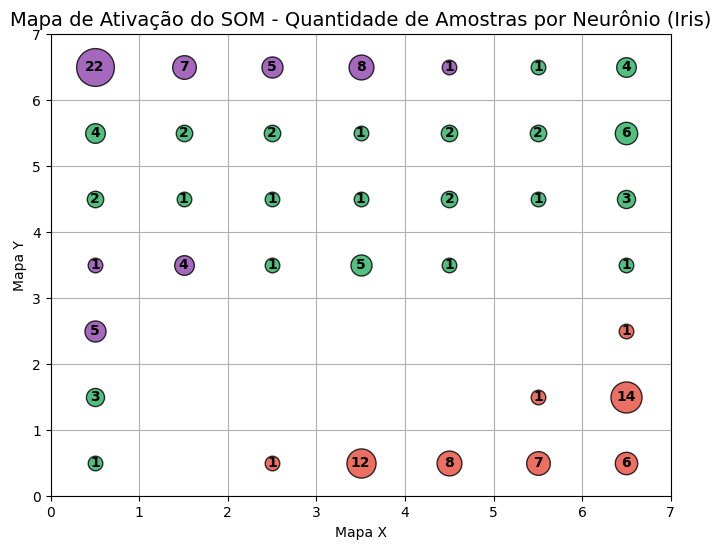

In [4]:
from collections import defaultdict
# Paleta de cores por classe
colors = {
    0: '#e74c3c',   # Setosa - vermelho
    1: '#27ae60',   # Versicolor - verde
    2: '#8e44ad'    # Virginica - roxo
}

# Agrupar as amostras por neurônio (BMU)
hits = defaultdict(list)

for idx, x in enumerate(X_scaled):
    bmu = som.winner(x)
    hits[bmu].append(y[idx])  # Guarda a classe real da amostra

plt.figure(figsize=(8, 6))

for pos, labels in hits.items():
    # Posição do neurônio no grid + deslocamento para centralizar os círculos
    x, y_pos = pos[0] + 0.5, pos[1] + 0.5
    count = len(labels)

    # Classe dominante (espécie mais comum atribuída ao neurônio)
    majority_class = max(set(labels), key=labels.count)

    # Cor do círculo com base na classe dominante
    plt.scatter(x, y_pos, s=80 + count * 30,
                color=colors[majority_class],
                edgecolor='k', alpha=0.8)

    # Texto no centro do círculo: quantidade de amostras
    plt.text(x, y_pos, str(count), fontsize=10,
             color='black', ha='center', va='center', weight='bold')

plt.xlim([0, som_x])
plt.ylim([0, som_y])
plt.title("Mapa de Ativação do SOM - Quantidade de Amostras por Neurônio (Iris)", fontsize=14)
plt.xlabel("Mapa X")
plt.ylabel("Mapa Y")
plt.grid(True)
plt.show()


# 4. Mapa de componentes

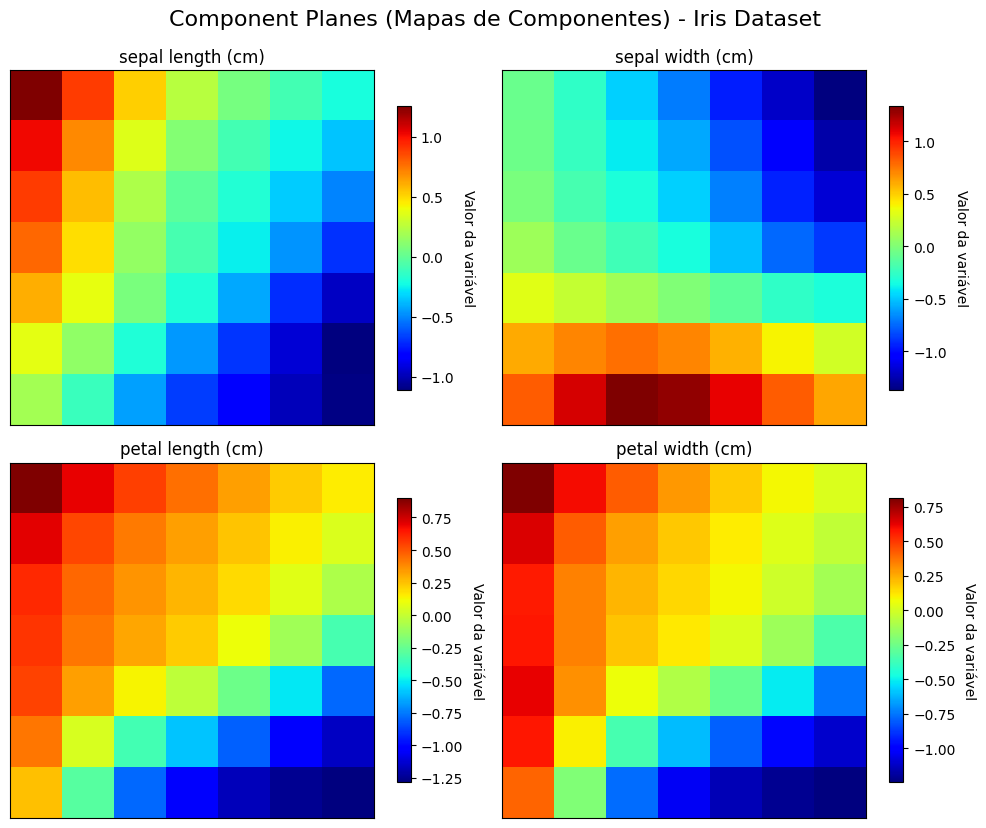

In [5]:
# Obter os pesos dos neurônios (shape: som_x, som_y, n_features)
weights = som.get_weights()

# Número de variáveis (atributos da base Iris)
n_features = weights.shape[2]

# Layout dos subplots
n_cols = 2
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 4 * n_rows))

# Criar um heatmap para cada variável
for i in range(n_features):
    ax = axes.flat[i]

    # Selecionar o plano da variável i
    plane = weights[:, :, i].T  # transpor para alinhar eixos visualmente

    im = ax.imshow(plane, cmap='jet', origin='lower', aspect='auto')
    ax.set_title(iris.feature_names[i])
    ax.set_xticks([])
    ax.set_yticks([])

    # Barra de cores
    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.ax.set_ylabel('Valor da variável', rotation=270, labelpad=15)

# Apagar subplots extras se existirem
for j in range(n_features, n_rows * n_cols):
    fig.delaxes(axes.flat[j])

plt.tight_layout()
plt.suptitle("Component Planes (Mapas de Componentes) - Iris Dataset", fontsize=16, y=1.03)
plt.show()


# 5. Visualização por pares de variáveis

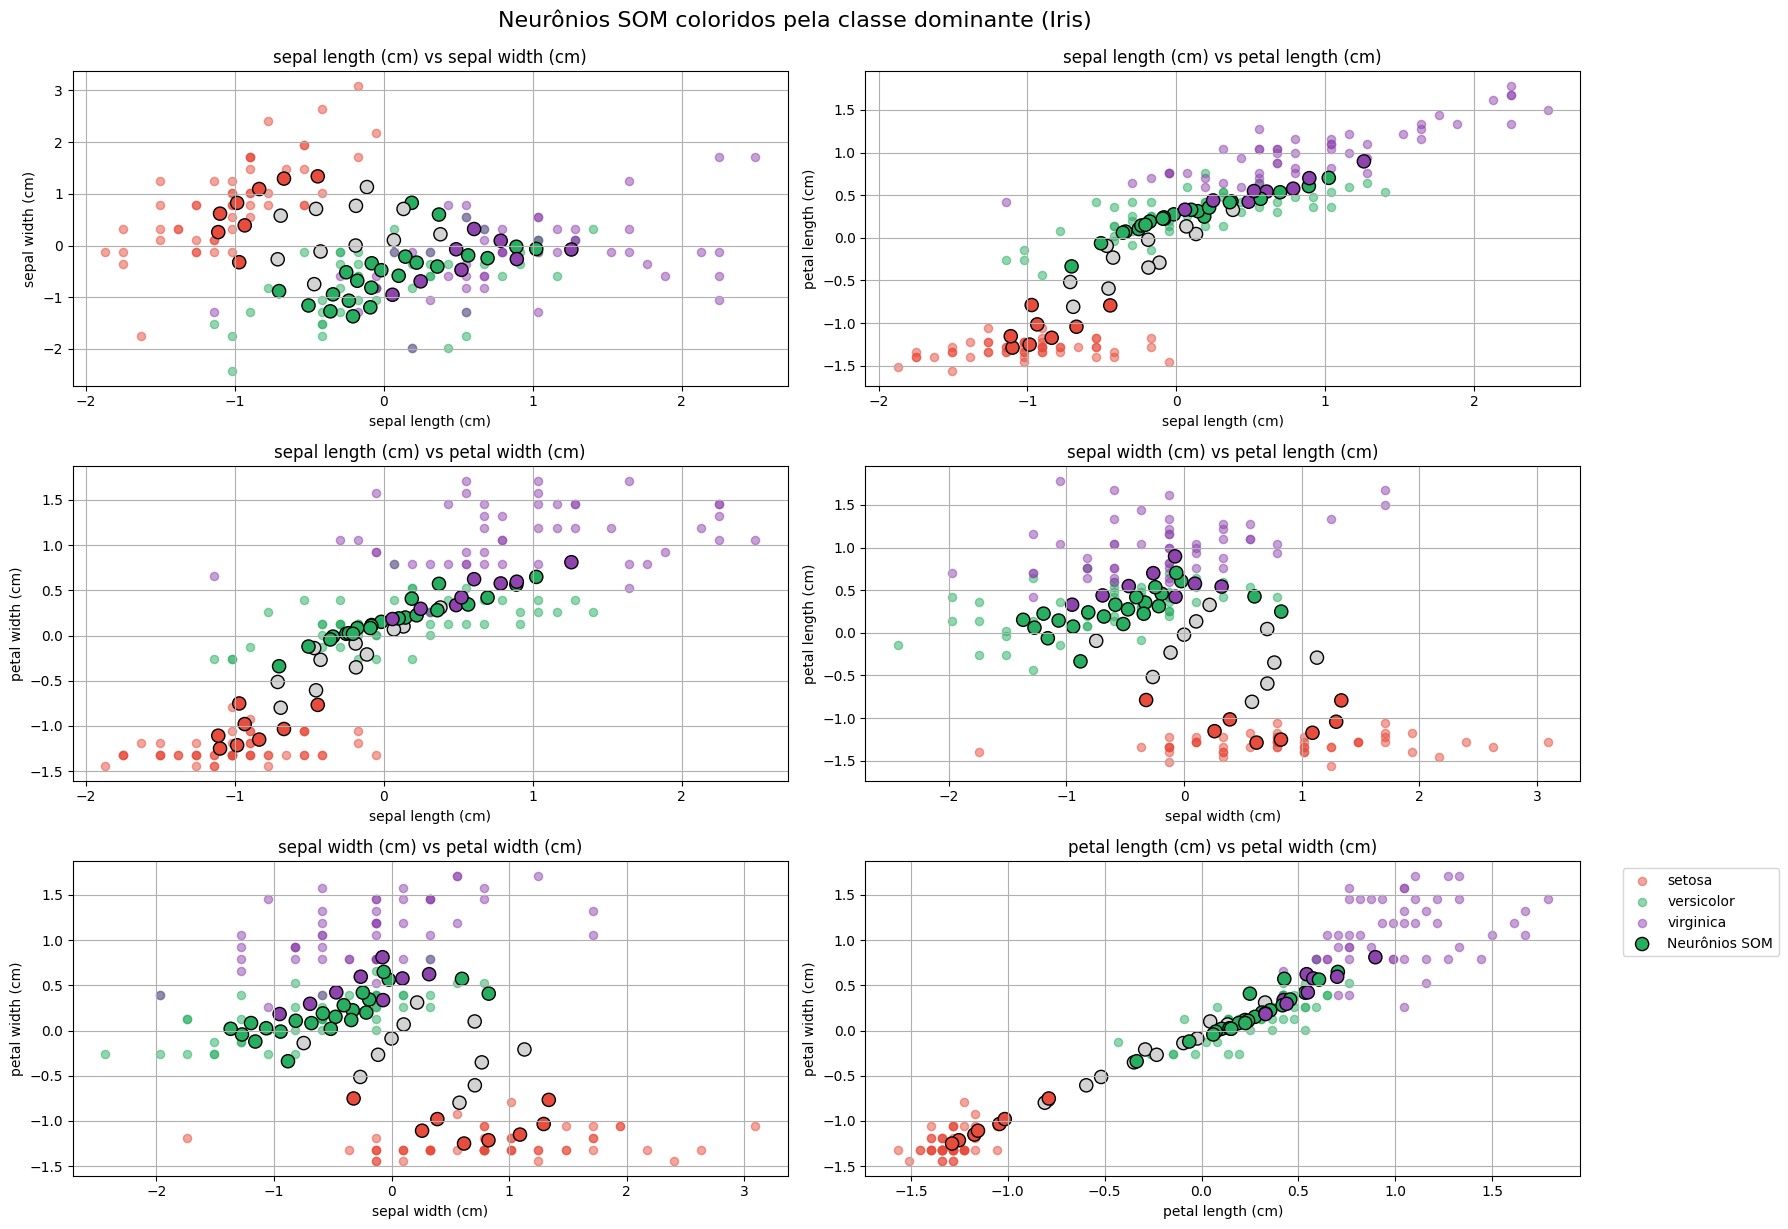

In [6]:
from collections import defaultdict

# Agrupar os dados por neurônio (BMU)
bmu_classes = defaultdict(list)

for idx, x in enumerate(X_scaled):
    bmu = som.winner(x)
    bmu_classes[bmu].append(y[idx])

# Determinar a classe dominante de cada neurônio
neuron_labels = {}
for bmu, class_list in bmu_classes.items():
    majority_class = max(set(class_list), key=class_list.count)
    neuron_labels[bmu] = majority_class

# Atributos e pesos dos neurônios
feature_names = iris.feature_names
n_features = X.shape[1]
weights = som.get_weights().reshape(-1, X.shape[1])

# Reorganizar os BMUs em lista com mesma ordem dos pesos
bmu_positions = [(i, j) for i in range(som_x) for j in range(som_y)]
neuron_colors = []

for pos in bmu_positions:
    if pos in neuron_labels:
        neuron_colors.append(colors[neuron_labels[pos]])
    else:
        neuron_colors.append('lightgray')  # neurônios não utilizados

# Plotar os neurônios coloridos pela classe que representam
plt.figure(figsize=(16, 12))
plot_idx = 1

for i in range(n_features):
    for j in range(i + 1, n_features):
        plt.subplot(3, 2, plot_idx)

        # Plotar os dados reais com cores por classe
        for class_index in np.unique(y):
            plt.scatter(X_scaled[y == class_index, i], X_scaled[y == class_index, j],
                        label=iris.target_names[class_index],
                        color=colors[class_index], alpha=0.5, s=35)

        # Plotar os neurônios, coloridos pela classe dominante
        plt.scatter(weights[:, i], weights[:, j], c=neuron_colors,
                    edgecolor='k', s=90, label='Neurônios SOM')

        plt.xlabel(feature_names[i])
        plt.ylabel(feature_names[j])
        plt.title(f'{feature_names[i]} vs {feature_names[j]}')
        plt.grid(True)
        plot_idx += 1

plt.tight_layout()
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.suptitle("Neurônios SOM coloridos pela classe dominante (Iris)", fontsize=16, y=1.02)
plt.show()


# *Plus: animação do treinamento*

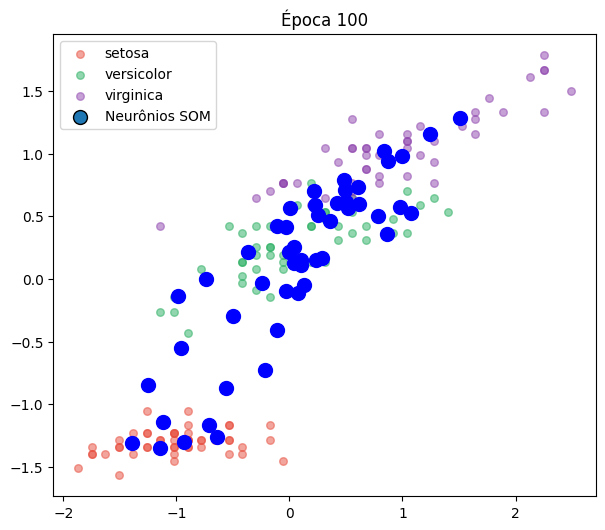

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from collections import defaultdict
from minisom import MiniSom

# Usar apenas dois atributos para visualização (ex: 0 = sepal length, 2 = petal length)
selected_features = [0, 2]
X_anim = X_scaled[:, selected_features]
y_anim = y  # mesma ordem

# Configuração do SOM
som_x, som_y = 7, 7
som = MiniSom(som_x, som_y, input_len=2, sigma=1.0, learning_rate=0.5)
som.random_weights_init(X_anim)
total_epochs = 1000

# Paleta de cores por classe
colors = {
    0: '#e74c3c',   # Setosa - vermelho
    1: '#27ae60',   # Versicolor - verde
    2: '#8e44ad'    # Virginica - roxo
}

# Armazenar pesos a cada update
weights_history = []

def train_with_tracking(som, data, total_epochs, update_every=100):
    for i in range(total_epochs):
        idx = np.random.randint(len(data))
        som.update(data[idx], som.winner(data[idx]), i, total_epochs)
        if (i + 1) % update_every == 0:
            weights_history.append(som.get_weights().reshape(-1, 2).copy())

train_with_tracking(som, X_anim, total_epochs, update_every=100)
# Definir posições fixas dos dados com cores por classe
fig, ax = plt.subplots(figsize=(7, 6))

for class_idx in np.unique(y_anim):
    plt.scatter(X_anim[y_anim == class_idx, 0],
                X_anim[y_anim == class_idx, 1],
                color=colors[class_idx], label=iris.target_names[class_idx],
                alpha=0.5, s=30)

neurons_plot = ax.scatter([], [], s=100, edgecolor='k', label='Neurônios SOM')

# Atualizar cores dos neurônios após o último frame
final_weights = weights_history[-1]

# Detectar limites automaticamente com base nos dados e nos pesos finais
all_x = np.concatenate([X_anim[:, 0], final_weights[:, 0]])
all_y = np.concatenate([X_anim[:, 1], final_weights[:, 1]])

# Adicionar margem de 5%
x_margin = (all_x.max() - all_x.min()) * 0.05
y_margin = (all_y.max() - all_y.min()) * 0.05

ax.set_xlim(all_x.min() - x_margin, all_x.max() + x_margin)
ax.set_ylim(all_y.min() - y_margin, all_y.max() + y_margin)

ax.set_title("Treinamento SOM - Atualização a cada 100 épocas")
ax.legend()

# Associar classe dominante aos neurônios após treino
bmu_classes = defaultdict(list)
for idx, x in enumerate(X_anim):
    bmu = som.winner(x)
    bmu_classes[bmu].append(y_anim[idx])

final_colors = []
positions = []

for i in range(som_x):
    for j in range(som_y):
        positions.append([i + 0.5, j + 0.5])
        if (i, j) in bmu_classes:
            majority_class = max(set(bmu_classes[(i, j)]), key=bmu_classes[(i, j)].count)
            final_colors.append(colors[majority_class])
        else:
            final_colors.append('lightgray')

# Função de atualização da animação
def update(frame):
    neurons_plot.set_offsets(weights_history[frame])
    if frame == len(weights_history) - 1:
        neurons_plot.set_color(final_colors)
    else:
        neurons_plot.set_color('blue')
    ax.set_title(f"Época {(frame + 1) * 100}")
    return neurons_plot,

# Criar a animação
anim = FuncAnimation(fig, update, frames=len(weights_history), interval=800, blit=False)

# Exibir
HTML(anim.to_jshtml())
